In [3]:
from models.PP3DR_depth_focal import PP3DR
import torch
from datasets.nrgbd_dataset import nrgbd_dataset
import matplotlib.pyplot as plt

In [4]:
model = PP3DR()

loaded_state_dict = torch.load("/vulcanscratch/hughma/PP3DR/depth-focal-sanity/PP3DR.pth", weights_only=True)
# The lines here are necessary if all the loaded state dict entries begin with an extra "module."
new_state_dict = {}
for key in loaded_state_dict:
    new_state_dict[key[7:]] = loaded_state_dict[key]
model.load_state_dict(new_state_dict)
print("post load")

model = model.eval().to("cuda")
dataset = nrgbd_dataset()
data = dataset[0]
print("post dataset")
for key in data:
    data[key] = data[key].unsqueeze(0)
with torch.amp.autocast("cuda", dtype = torch.bfloat16), torch.no_grad():
    pred = model(data['images'].to("cuda"), data['rope_x'].to("cuda"), data['rope_y'].to("cuda"))
print("post pred")
for key in pred:
    pred[key] = pred[key].to(torch.float32).cpu().numpy(force=True)
    print(f"{key}: {pred[key].shape}")
print("done")

post load


Precomputing NRGBD image file paths: 9it [00:00, 16.87it/s]


post dataset


/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/torch/_dynamo/utils.py:3694: UserWarning: Mismatch dtype between input and weight: input dtype = c10::BFloat16, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /home/task_177771236509760/croot/libtorch_1777712413063/work/aten/src/ATen/native/layer_norm.cpp:344.)
  return node.target(*args, **kwargs)  # type: ignore[operator]


post pred
log_depths: (1, 10, 512, 512)
fx: (1, 10)
fy: (1, 10)
cx: (1, 10)
cy: (1, 10)
relative_camera_translations: (1, 9, 3)
relative_camera_rotations: (1, 9, 3, 3)
done


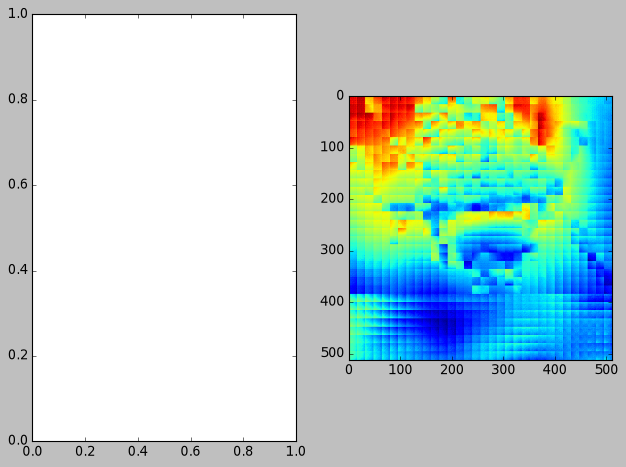

In [5]:
# plt.style.use("seaborn-v0_8-darkgrid")
plt.style.use("classic")
fig, (a1, a2) = plt.subplots(1, 2)
# a1.scatter(pred['XY_rays'][0, 0][..., 0], pred['XY_rays'][0, 0][..., 1])
a2.imshow(pred['log_depths'][0][0])
fig.tight_layout()

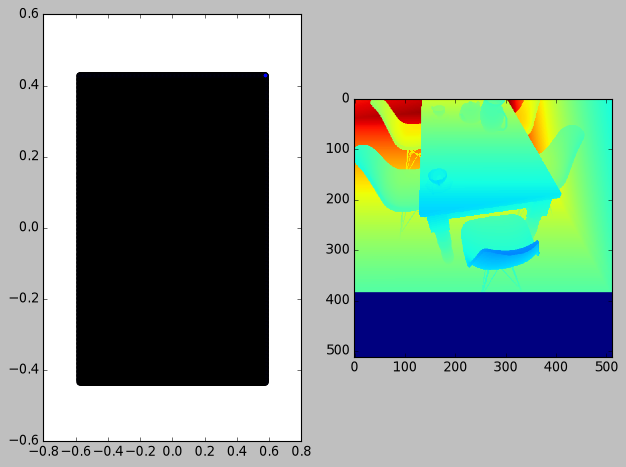

In [6]:
def obtain_gt_3D_points(gt):
    """
    Parameters
    ----------
    gt

    Returns
    -------
    (B, L, H, W, 3) of world-frame 3D-coordinates, unprojected from gt, UN-NORMALISED.
    We won't normalize here; we'll normalize in the main function.
    """
    B, L, H, W = gt['depths'].shape
    y, x = torch.meshgrid(torch.arange(H, device="cuda"), torch.arange(W, device="cuda"), indexing='ij') # (H, W)
    y, x = y.view(1, 1, H, W), x.view(1, 1, H, W)
    Z = gt['depths'].cuda() # (B, L, H, W), already moved to cuda
    gt['intrinsics'] = gt['intrinsics'].to("cuda", non_blocking = True)
    fx, fy = gt['intrinsics'][..., 0, 0].view(B, L, 1, 1), gt['intrinsics'][..., 1, 1].view(B, L, 1, 1)
    cx, cy = gt['intrinsics'][..., 0, 2].view(B, L, 1, 1), gt['intrinsics'][..., 1, 2].view(B, L, 1, 1)
    X = (x - cx) * Z / fx # (B, L, H, W)
    Y = (y - cy) * Z / fy # (B, L, H, W)

    return torch.stack((X, Y, Z), dim=-1) # (B, N, H, W, 3)

gt_points = obtain_gt_3D_points(data) # (B, N, H, W, 3)
gt_points = gt_points[0, 0]
gt_xy = gt_points[..., :2] / gt_points[..., 2:]
gt_xy = gt_xy.numpy(force = True)
fig, (a1, a2) = plt.subplots(1, 2)
a1.scatter(gt_xy[..., 0], gt_xy[..., 1])
a2.imshow(data['depths'][0][0])
fig.tight_layout()